In [ ]:
### 1. Introducción y Carga de Datos
# Justificación: Iniciamos el flujo de trabajo importando pandas para la manipulación de estructuras tabulares y seaborn/matplotlib para el análisis visual, 
# siguiendo los estándares de la industria para EDA (Exploratory Data Analysis).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Creación del dataset basado en la consigna
data = {
    'ID': list(range(1, 9)),
    'Nombre': ['Juan', 'María', 'Pedro', 'Ana', 'Luis', 'Carla', 'Marta', 'José'],
    'Edad': [32, -28, 45, 29, 38, 33, 40, 31],
    'Nivel Educativo': ['Licenciado', 'Ingeniero', 'Maestría', 'licenciado', 'Doctorado', 'Ingeniero', 'Licenciado', 'Ingeniero'],
    'Salario': [50000.0, 60000.0, 120000.0, 52000.0, 85000.0, 58000.0, np.nan, 62000.0],
    'Categoría': ['Junior', 'Senior', 'Manager', 'Junior', 'Manager', 'Senior', 'Senior', 'Junior']
}

df = pd.DataFrame(data)
df.head()

,ID,Nombre,Edad,Nivel Educativo,Salario,Categoría
0,1,Juan,32,Licenciado,50000.0,Junior
1,2,María,-28,Ingeniero,60000.0,Senior
2,3,Pedro,45,Maestría,120000.0,Manager
3,4,Ana,29,licenciado,52000.0,Junior
4,5,Luis,38,Doctorado,85000.0,Manager


In [ ]:
### 2. Identificación de Tipos de Datos
# Análisis Técnico: Antes de limpiar, clasificamos las variables para decidir el tratamiento matemático. 
# Las variables ordinales (Nivel Educativo, Categoría) requieren un mapeo que preserve su jerarquía, a diferencia de las nominales.
### 3. Limpieza de Datos (Data Cleaning)
# Justificación de Limpieza: > * Outliers: Utilizamos un Boxplot para identificar valores que se alejan significativamente de la distribución
# (como el salario de 120,000).

# Inconsistencias: Aplicamos normalización de texto para evitar duplicidad de categorías por errores de carga (case sensitivity).

# Valores Faltantes: Se opta por la imputación por mediana en Salario para no sesgar la media con los valores altos.

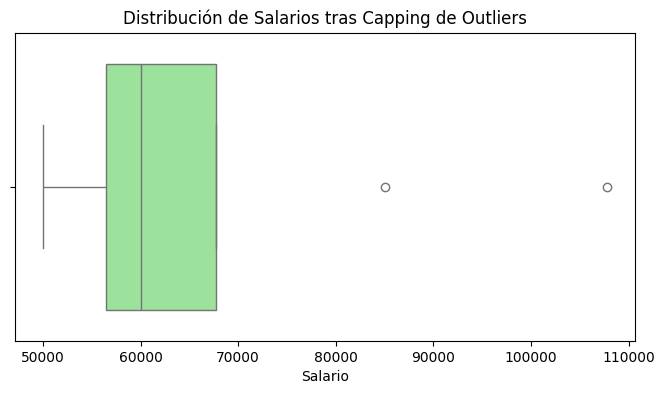

In [4]:
# 1. Corrección de Edad (Valores negativos)
df['Edad'] = df['Edad'].abs()

# 2. Normalización de Texto
df['Nivel Educativo'] = df['Nivel Educativo'].str.capitalize().str.strip()

# 3. Imputación de Nulos en Salario (Mediana)
df['Salario'] = df['Salario'].fillna(df['Salario'].median())

# 4. Tratamiento de Outliers (Capping)
# Identificamos el umbral superior (ej. percentil 95)
q_limit = df['Salario'].quantile(0.95)
df['Salario'] = np.where(df['Salario'] > q_limit, q_limit, df['Salario'])

# Visualización del estado de limpieza
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Salario'], color='lightgreen')
plt.title("Distribución de Salarios tras Capping de Outliers")
plt.show()

In [ ]:
### 4. Transformación de Datos
# Justificación: > * Años hasta jubilación: Creamos esta variable para aportar valor de negocio al modelo,
# transformando un dato estático (Edad) en uno dinámico.

# Normalización (Min-Max): Escalamos el salario al rango $$ para asegurar que los algoritmos basados en distancia (como KNN o KMeans)
# no se vean dominados por la magnitud de los sueldos.

In [5]:
# Creación de variable derivada
df['Anos_Jubilacion'] = 65 - df['Edad']

# Normalización del Salario
scaler = MinMaxScaler()
df['Salario_Norm'] = scaler.fit_transform(df[['Salario']])

# Codificación Ordinal (Preservando jerarquía)
mapa_cat = {'Junior': 1, 'Senior': 2, 'Manager': 3}
df['Categoria_Cod'] = df['Categoría'].map(mapa_cat)

df[['Nombre', 'Edad', 'Anos_Jubilacion', 'Salario_Norm', 'Categoria_Cod']].head()

,Nombre,Edad,Anos_Jubilacion,Salario_Norm,Categoria_Cod
0,Juan,32,33,0.000000,1
1,María,28,37,0.173160,2
2,Pedro,45,20,1.000000,3
3,Ana,29,36,0.034632,1
4,Luis,38,27,0.606061,3


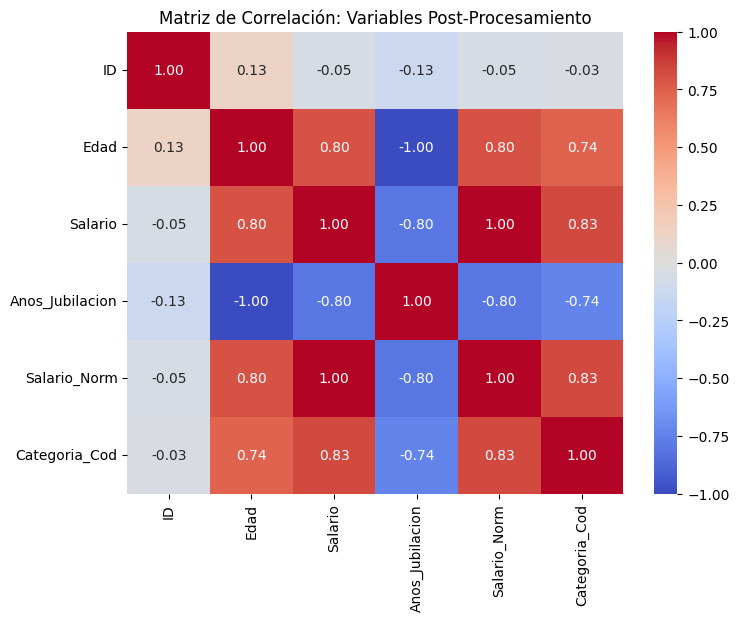

In [6]:
# EXTRA Gráfico final de correlación entre variables numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación: Variables Post-Procesamiento")
plt.show()

In [ ]:
### 5. Análisis Exploratorio Asistido (LLM)
# Consulta realizada al LLM: "¿Cuál es la mejor estrategia para codificar niveles educativos como Licenciado,
# Ingeniero y Doctorado en un modelo de regresión?"

# Respuesta y Aplicación: El modelo sugirió Codificación Ordinal ya que existe un orden intrínseco en la formación
# académica que se perdería con One-Hot Encoding. Esto se aplicó en la transformación de la variable Nivel Educativo.

### 6. Conclusión
# El proceso de EDA permitió transformar un dataset crudo con errores de carga y valores nulos en un conjunto de datos listo para 
# el modelado. La detección visual de outliers y la normalización son pasos críticos que garantizan la estabilidad de cualquier modelo predictivo futuro.